In [1]:
import cytotrace2_py as cytotrace2
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Running CytoTRACE2...
cytotrace2: Input parameters
    Input file: ../data/CCG1106_075_T1_TP53_expression_matrix_raw.txt
    Species: human
    Parallelization enabled: True
    Batch size: 20000
    Smoothing batch size: 1000
    Seed: 14
    Output directory: cytotrace2_results
    Plotting enabled: True
    Verbose mode enabled: True
    User-provided limit for number of cores to use: None
       ...11 cores detected. CytoTRACE 2 will run using up to 5/11 cores.
cytotrace2: Loading dataset
cytotrace2: Dataset characteristics
    Number of input genes:  26220
    Number of input cells:  1955
cytotrace2: Checking models...
All model files are present.
cytotrace2: Computing UMAP embeddings from full expression
cytotrace2: The passed batch_size is greater than the number of cells in the subsample. 
    Now setting batch_size to 1955.
cytotrace2: Preprocessing
cytotrace2: Running 1 prediction batch(es) sequentially using 5 cores per batch.


/Users/shreyaraman/Library/Python/3.12/lib/python/site-packages/torch/_utils.py:358: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  result = torch.sparse_coo_tensor(


cytotrace2: Initiated processing batch 1/1 with 1955 cells
    Mapped 13779 input gene names to mouse orthologs
    13778 input genes are present in the model features.
cytotrace2: Performing initial model prediction
cytotrace2: Performing smoothing by diffusion
cytotrace2: Performing smoothing by adaptive KNN
cytotrace2: Plotting outputs
cytotrace2: Finished.
CytoTRACE2 completed!

Results keys: Index(['CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative',
       'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency'],
      dtype='object')


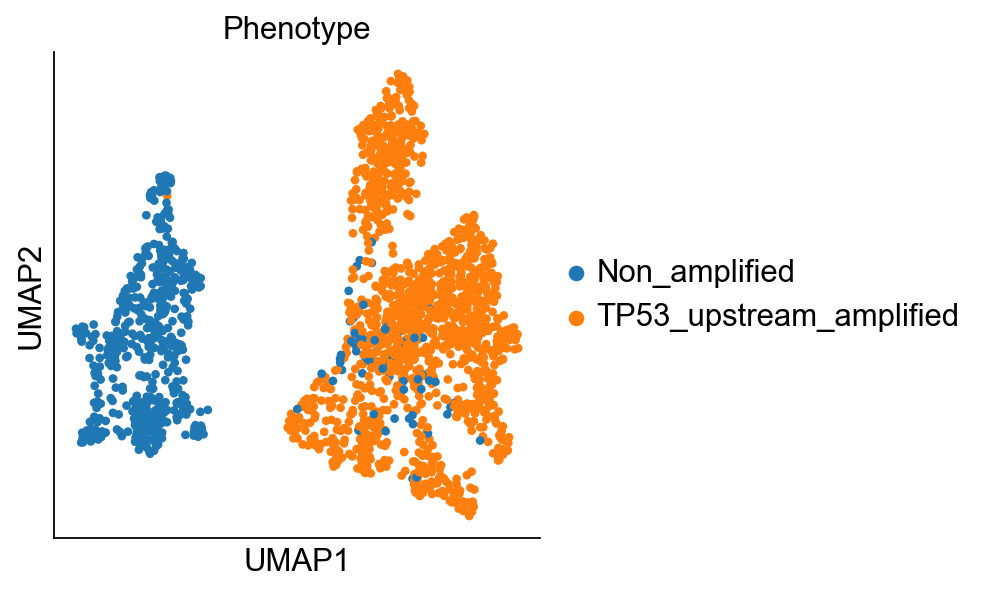

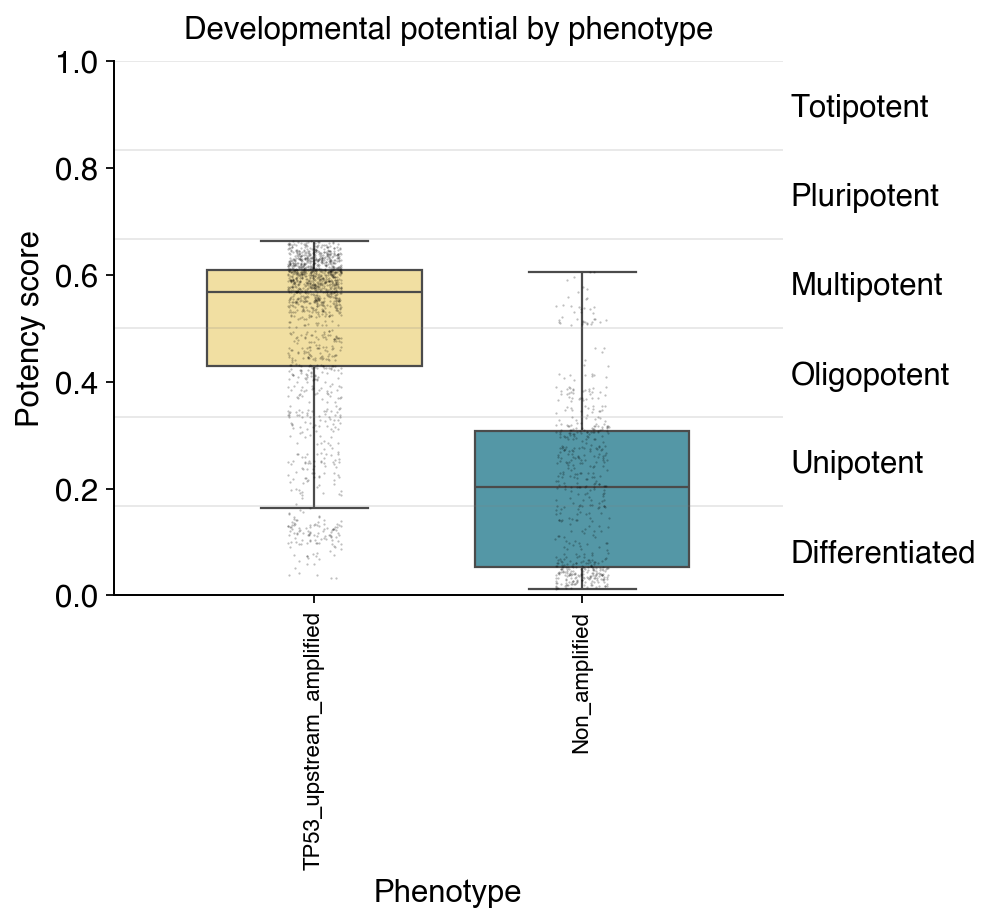

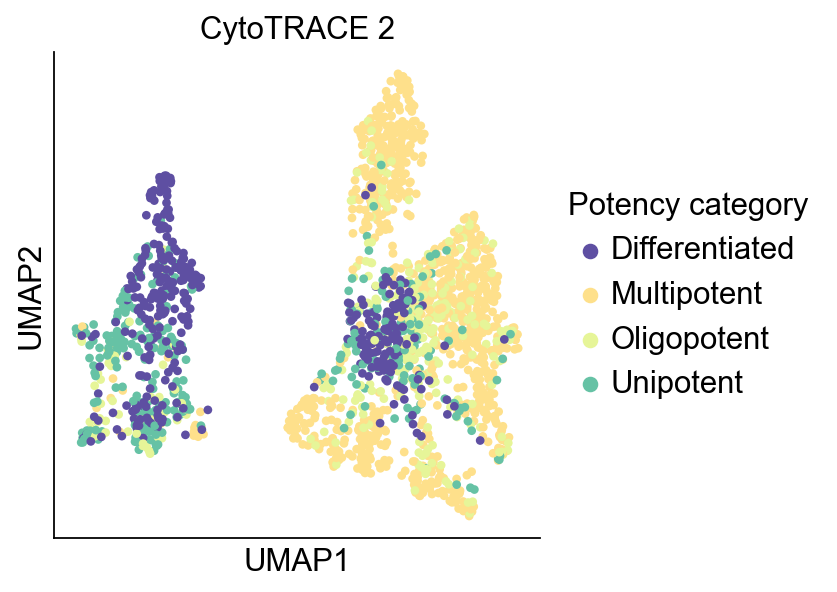

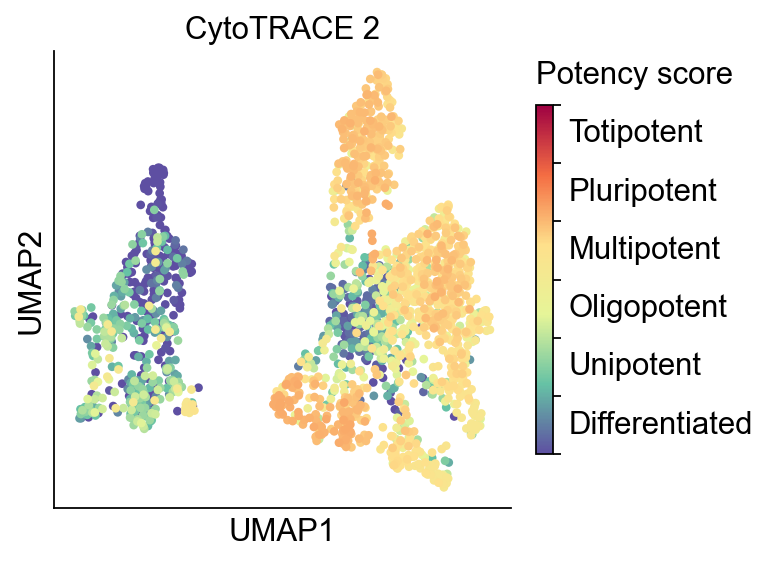

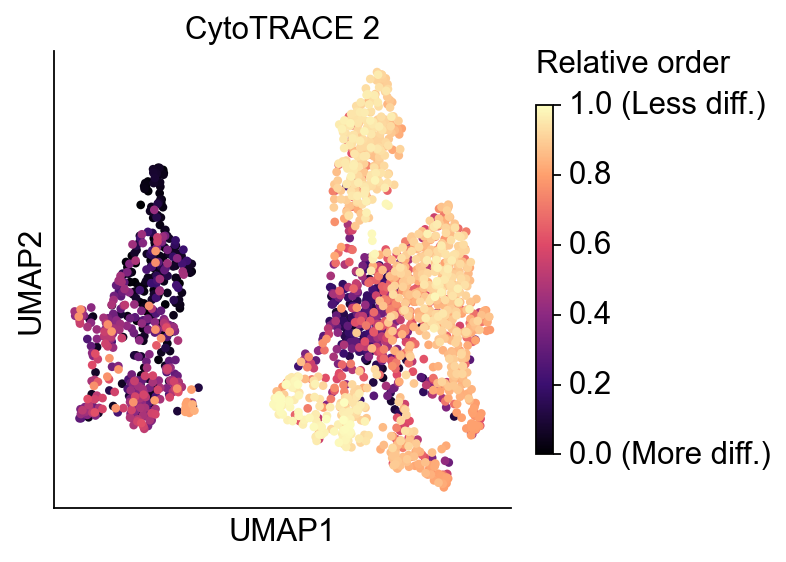

In [2]:
print("Running CytoTRACE2...")

results = cytotrace2.cytotrace2(
    input_path='../data/CCG1106_075_T1_TP53_expression_matrix_raw.txt',
    annotation_path='../data/CCG1106_075_T1_TP53_phenotype.txt',
    species='human'
)

print("CytoTRACE2 completed!")
print("\nResults keys:", results.keys())


Results preview:
   CytoTRACE2_Score           cell_id                phenotype
0          0.611746  GGTATTGGTTCCGTCT  TP53_upstream_amplified
1          0.633456  TGCCCTACAGGCAGTA  TP53_upstream_amplified
2          0.636447  CAACCAATCAGTTAGC  TP53_upstream_amplified
3          0.622660  CCTAAAGGTCGCCATG  TP53_upstream_amplified
4          0.631258  CCTCTGAGTTGTCGCG  TP53_upstream_amplified

TP53 upstream amplified - mean CytoTRACE2 score: 0.498 (n=1382)
Non amplified - mean CytoTRACE2 score: 0.204 (n=573)

Mann-Whitney U test p-value: 9.72e-168


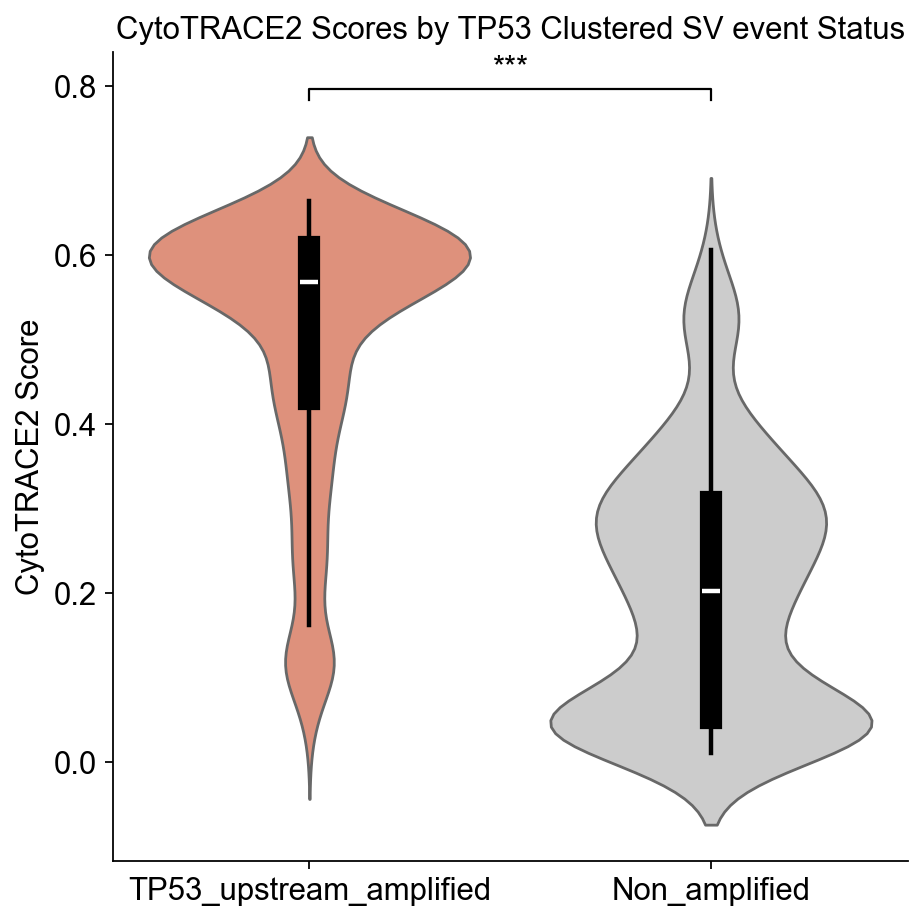

In [5]:
# Extract the results
cytotrace_scores = results['CytoTRACE2_Score'] 
phenotype_data = pd.read_csv('../data/CCG1106_075_T1_TP53_phenotype.txt', sep='\t')

# Merge scores with phenotypes
results_df = pd.DataFrame(cytotrace_scores)
results_df = results_df.merge(phenotype_data, left_index=True, right_on='cell_id')

print("\nResults preview:")
print(results_df.head())

# Compare groups
amplified_scores = results_df[results_df['phenotype'] == 'TP53_upstream_amplified']['CytoTRACE2_Score']
non_amplified_scores = results_df[results_df['phenotype'] == 'Non_amplified']['CytoTRACE2_Score']

print(f"\nTP53 upstream amplified - mean CytoTRACE2 score: {amplified_scores.mean():.3f} (n={len(amplified_scores)})")
print(f"Non amplified - mean CytoTRACE2 score: {non_amplified_scores.mean():.3f} (n={len(non_amplified_scores)})")

# Statistical test
stat, pval = stats.mannwhitneyu(amplified_scores, non_amplified_scores, alternative='two-sided')
print(f"\nMann-Whitney U test p-value: {pval:.2e}")

def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

palette = {
    'TP53_upstream_amplified': '#ee876cdb',
    'Non_amplified': '#CCCCCC'
}

fig, ax = plt.subplots(figsize=(6, 6))
sns.violinplot(
    data=results_df,
    x='phenotype',
    y='CytoTRACE2_Score',
    ax=ax,
    palette=palette,
    inner='box',
    inner_kws=dict(
        box_width=10,
        whis_width=2,
        color='black',
    )
)
ax.grid(False)
sns.despine()

# Add significance bracket
y_max = results_df['CytoTRACE2_Score'].max() + 0.1
y_range = results_df['CytoTRACE2_Score'].max() - results_df['CytoTRACE2_Score'].min()
bar_y = y_max + y_range * 0.05 
tip_y = bar_y - y_range * 0.02

ax.plot([0, 0, 1, 1], [tip_y, bar_y, bar_y, tip_y], lw=1, color='black')
ax.text(0.5, bar_y + y_range * 0.01, get_stars(pval), ha='center', va='bottom', fontsize=14)

ax.set_title('CytoTRACE2 Scores by TP53 Clustered SV event Status')
ax.set_ylabel('CytoTRACE2 Score')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig(f"../outputs/cytotrace2_output_CCG1106_075_T1_TP53/cytotrace_score_by_event_violin.pdf", dpi=300)
plt.show()